In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Creating a new list to match county names with FIPS codes since none of the datasets already had them inherently.

In [220]:
COUNTY_TO_FIPS = {
    'Davidson': '47037',
    'Maury': '47119',
    'Rutherford': '47149',
    'Sumner': '47165',
    'Williamson': '47187'
}
TARGET_FIPS = list(COUNTY_TO_FIPS.values())
FIPS_TO_COUNTY = {v: k for k, v in COUNTY_TO_FIPS.items()}

In [221]:
pd.set_option('display.max_columns', None)

In [222]:
%pip install pandas xlrd openpyxl

Note: you may need to restart the kernel to use updated packages.


Reading in all datasets

In [223]:
fhfa = pd.read_csv('../data/fhfadata.csv')

C:\Users\nicks\AppData\Local\Temp\ipykernel_34704\1499586651.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  fhfa = pd.read_csv('../data/fhfadata.csv')


In [270]:
pricing = pd.read_excel('../data/pricing.xlsx')

In [224]:
permits2020 = pd.read_excel('../data/2020permits.xlsx')

Going through data sets to correct column names that did not transfer properly from the sources.  Had to do this for almost all sets.

In [225]:
permits2020 = permits2020.rename(columns={'Survey': 'Year', 'FIPS': 'State Code', 'FIPS.1': 'County Code', 'Unnamed: 6': 'Buildings', 'Unnamed: 8': 'Value', 'Unnamed: 9': 'Buildings', 'Unnamed: 11': 'Value', 'Unnamed: 12': 'Buildings', 'Unnamed: 14': 'Value', 'Unnamed: 15': 'Buildings', 'Unnamed: 17': 'Value', 'Unnamed: 18': 'Buildings', 'Unnamed: 20': 'Value', 'Unnamed: 21': 'Buildings', 'Unnamed: 23': 'Value', 'Unnamed: 24': 'Buildings', 'Unnamed: 26': 'Value', 'Unnamed: 27': 'Buildings', 'Unnamed: 29': 'Value'})

In [226]:
permits2021 = pd.read_excel('../data/2021permits.xlsx')

In [227]:
permits2021 = permits2021.rename(columns={'Survey': 'Year', 'FIPS': 'State Code', 'FIPS.1': 'County Code', 'Unnamed: 6': 'Buildings', 'Unnamed: 8': 'Value', 'Unnamed: 9': 'Buildings', 'Unnamed: 11': 'Value', 'Unnamed: 12': 'Buildings', 'Unnamed: 14': 'Value', 'Unnamed: 15': 'Buildings', 'Unnamed: 17': 'Value', 'Unnamed: 18': 'Buildings', 'Unnamed: 20': 'Value', 'Unnamed: 21': 'Buildings', 'Unnamed: 23': 'Value', 'Unnamed: 24': 'Buildings', 'Unnamed: 26': 'Value', 'Unnamed: 27': 'Buildings', 'Unnamed: 29': 'Value'})

In [228]:
permits2022 = pd.read_excel('../data/2022permits.xlsx')

In [229]:
permits2022 = permits2022.rename(columns={'Survey': 'Year', 'FIPS': 'State Code', 'FIPS.1': 'County Code', 'Unnamed: 6': 'Buildings', 'Unnamed: 8': 'Value', 'Unnamed: 9': 'Buildings', 'Unnamed: 11': 'Value', 'Unnamed: 12': 'Buildings', 'Unnamed: 14': 'Value', 'Unnamed: 15': 'Buildings', 'Unnamed: 17': 'Value', 'Unnamed: 18': 'Buildings', 'Unnamed: 20': 'Value', 'Unnamed: 21': 'Buildings', 'Unnamed: 23': 'Value', 'Unnamed: 24': 'Buildings', 'Unnamed: 26': 'Value', 'Unnamed: 27': 'Buildings', 'Unnamed: 29': 'Value'})

In [230]:
permits2023 = pd.read_excel('../data/2023permits.xlsx')

In [231]:
permits2023 = permits2023.rename(columns={'Survey': 'Year', 'FIPS': 'State Code', 'FIPS.1': 'County Code', 'Unnamed: 6': 'Buildings', 'Unnamed: 8': 'Value', 'Unnamed: 9': 'Buildings', 'Unnamed: 11': 'Value', 'Unnamed: 12': 'Buildings', 'Unnamed: 14': 'Value', 'Unnamed: 15': 'Buildings', 'Unnamed: 17': 'Value', 'Unnamed: 18': 'Buildings', 'Unnamed: 20': 'Value', 'Unnamed: 21': 'Buildings', 'Unnamed: 23': 'Value', 'Unnamed: 24': 'Buildings', 'Unnamed: 26': 'Value', 'Unnamed: 27': 'Buildings', 'Unnamed: 29': 'Value'})

In [232]:
permits2024 = pd.read_excel('../data/2024permits.xlsx')

In [233]:
permits2024 = permits2024.rename(columns={'Survey': 'Year', 'FIPS': 'State Code', 'FIPS.1': 'County Code', 'Unnamed: 6': 'Buildings', 'Unnamed: 8': 'Value', 'Unnamed: 9': 'Buildings', 'Unnamed: 11': 'Value', 'Unnamed: 12': 'Buildings', 'Unnamed: 14': 'Value', 'Unnamed: 15': 'Buildings', 'Unnamed: 17': 'Value', 'Unnamed: 18': 'Buildings', 'Unnamed: 20': 'Value', 'Unnamed: 21': 'Buildings', 'Unnamed: 23': 'Value', 'Unnamed: 24': 'Buildings', 'Unnamed: 26': 'Value', 'Unnamed: 27': 'Buildings', 'Unnamed: 29': 'Value'})

In [234]:
permits2025 = pd.read_excel('../data/2025permits.xlsx')

In [235]:
permits2025 = permits2025.rename(columns={'Survey': 'Year', 'FIPS': 'State Code', 'FIPS.1': 'County Code', 'Unnamed: 6': 'Buildings', 'Unnamed: 8': 'Value', 'Unnamed: 9': 'Buildings', 'Unnamed: 11': 'Value', 'Unnamed: 12': 'Buildings', 'Unnamed: 14': 'Value', 'Unnamed: 15': 'Buildings', 'Unnamed: 17': 'Value', 'Unnamed: 18': 'Buildings', 'Unnamed: 20': 'Value', 'Unnamed: 21': 'Buildings', 'Unnamed: 23': 'Value', 'Unnamed: 24': 'Buildings', 'Unnamed: 26': 'Value', 'Unnamed: 27': 'Buildings', 'Unnamed: 29': 'Value'})

Combining all individual permit sets into one master set with all years together.

In [236]:
permit_dfs = [
    (permits2020, 2020), (permits2021, 2021), (permits2022, 2022),
    (permits2023, 2023), (permits2024, 2024), (permits2025, 2025)
]

combined_permits = []

for df, year in permit_dfs:
    temp_df = df.copy()
    
    state_col = temp_df['State Code'].astype(str).str.split('.').str[0].str.zfill(2)
    county_col = temp_df['County Code'].astype(str).str.split('.').str[0].str.zfill(3)
    
    temp_df['fips'] = state_col + county_col
    
    filtered = temp_df[temp_df['fips'].isin(TARGET_FIPS)].copy()
    
    if not filtered.empty:
        filtered['year'] = year
        filtered['clean_county'] = filtered['fips'].map(FIPS_TO_COUNTY)
        
        if 'Buildings' in filtered.columns:
            filtered['building_permits'] = filtered['Buildings'].iloc[:, 0] if isinstance(filtered['Buildings'], pd.DataFrame) else filtered['Buildings']
        else:
            filtered['building_permits'] = filtered.iloc[:, 5]
            
        combined_permits.append(filtered[['fips', 'clean_county', 'year', 'building_permits']])
permits_long = pd.concat(combined_permits, ignore_index=True)
permits_long['building_permits'] = pd.to_numeric(permits_long['building_permits'], errors='coerce')

In [237]:
countypop = pd.read_excel('../data/countypop.xlsx')

Cleaning up column names again for dataset and mapping to FIPS codes

In [238]:
countypop= countypop.rename(columns={'table with row headers in column A and column headers in rows 3 through 4 (leading dots indicate sub-parts)': 'County', 'Unnamed: 1': 'Estimates Base', 'Unnamed: 2': '2020', 'Unnamed: 3': '2021', 'Unnamed: 4': '2022', 'Unnamed: 5': '2023', 'Unnamed: 6': '2024', 'Unnamed: 7': '2025'})

In [239]:
pop_clean = countypop.iloc[3:].copy()
pop_clean['clean_county'] = (
    pop_clean['County']
    .astype(str)
    .str.replace(r'^\.', '', regex=True)
    .str.replace(' County, Tennessee', '', case=False, regex=False)
    .str.strip()
)
pop_clean['fips'] = pop_clean['clean_county'].map(COUNTY_TO_FIPS)
pop_clean = pop_clean[pop_clean['fips'].notnull()].copy()
pop_long = pop_clean.melt(
    id_vars=['fips', 'clean_county'],
    value_vars=['2020', '2021', '2022', '2023', '2024', '2025'],
    var_name='year',
    value_name='population'
)

pop_long['year'] = pop_long['year'].astype(int)
pop_long['population'] = pd.to_numeric(pop_long['population'], errors='coerce')

Cleaning up column names for each of the unemployment sets

In [241]:
davidsonunemploy = pd.read_excel('../data/davidsonunemploy.xlsx')

C:\Users\nicks\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [242]:
davidsonunemploy = davidsonunemploy.rename(columns={'Local Area Unemployment Statistics': 'Series ID', 'Unnamed: 1': 'Year', 'Unnamed: 2': 'Period', 'Unnamed: 3': 'Value'})

In [243]:
mauryunemploy = pd.read_excel('../data/mauryunemploy.xlsx')

C:\Users\nicks\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [244]:
mauryunemploy = mauryunemploy.rename(columns={'Local Area Unemployment Statistics': 'Series ID', 'Unnamed: 1': 'Year', 'Unnamed: 2': 'Period', 'Unnamed: 3': 'Value'})

In [245]:
rutherfordunemploy = pd.read_excel('../data/rutherfordunemploy.xlsx')

C:\Users\nicks\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [246]:
rutherfordunemploy = rutherfordunemploy.rename(columns={'Local Area Unemployment Statistics': 'Series ID', 'Unnamed: 1': 'Year', 'Unnamed: 2': 'Period', 'Unnamed: 3': 'Value'})

In [247]:
sumnerunemploy = pd.read_excel('../data/sumnerunemploy.xlsx')

C:\Users\nicks\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [248]:
sumnerunemploy = sumnerunemploy.rename(columns={'Local Area Unemployment Statistics': 'Series ID', 'Unnamed: 1': 'Year', 'Unnamed: 2': 'Period', 'Unnamed: 3': 'Value'})

In [249]:
williamsonunemploy = pd.read_excel('../data/williamsonunemploy.xlsx')

C:\Users\nicks\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [250]:
williamsonunemploy = williamsonunemploy.rename(columns={'Local Area Unemployment Statistics': 'Series ID', 'Unnamed: 1': 'Year', 'Unnamed: 2': 'Period', 'Unnamed: 3': 'Value'})

Creating a dictionary and empty list to go through each of the unemployment sets, match them to FIPS codes, and combine them into one master set.

In [251]:
unemploy_dict = {
    'Davidson': davidsonunemploy,
    'Maury': mauryunemploy,
    'Rutherford': rutherfordunemploy,
    'Sumner': sumnerunemploy,
    'Williamson': williamsonunemploy
}

unemploy_list = []

for county_name, df in unemploy_dict.items():
    temp_df = df.copy()
    temp_df['clean_county'] = county_name
    temp_df['fips'] = COUNTY_TO_FIPS[county_name]
    unemploy_list.append(temp_df)

unemploy_combined = pd.concat(unemploy_list, ignore_index=True)
unemploy_combined['Year'] = pd.to_numeric(unemploy_combined['Year'], errors='coerce')
unemploy_combined['Value'] = pd.to_numeric(unemploy_combined['Value'], errors='coerce')
unemploy_annual = (
    unemploy_combined
    .groupby(['fips', 'clean_county', 'Year'])['Value']
    .mean()
    .reset_index()
    .rename(columns={'Year': 'year', 'Value': 'unemployment_rate'})
)

Merging all of the datasets into one combined set with all the new information

In [253]:
combined_df = pop_long.merge(permits_long[['fips', 'year', 'building_permits']], on=['fips', 'year'], how='left') \
                   .merge(unemploy_annual[['fips', 'year', 'unemployment_rate']], on=['fips', 'year'], how='left')
combined_df['permits_per_1k'] = (combined_df['building_permits'] / combined_df['population']) * 1000

In [262]:
combined_df.head(40)

,fips,clean_county,year,population,building_permits,unemployment_rate,permits_per_1k
0,47037,Davidson,2020,716153,3980.0,8.176923,5.557472
1,47119,Maury,2020,101812,1347.0,7.969231,13.230268
2,47149,Rutherford,2020,343285,2744.0,7.084615,7.993358
3,47165,Sumner,2020,197416,1284.0,6.676923,6.504032
4,47187,Williamson,2020,249614,1798.0,4.976923,7.203122
5,47037,Davidson,2021,701450,3857.0,4.361538,5.498610
6,47119,Maury,2021,105005,NaN,4.823077,NaN
7,47149,Rutherford,2021,351202,3278.0,3.584615,9.333660
8,47165,Sumner,2021,200578,1604.0,3.530769,7.996889
9,47187,Williamson,2021,256192,NaN,2.715385,NaN


--- County Population Growth (2020-2021) ---
clean_county  Pop_Growth_pct
    Davidson       -2.053053
       Maury        3.136173
  Rutherford        2.306247
      Sumner        1.601694
  Williamson        2.635269


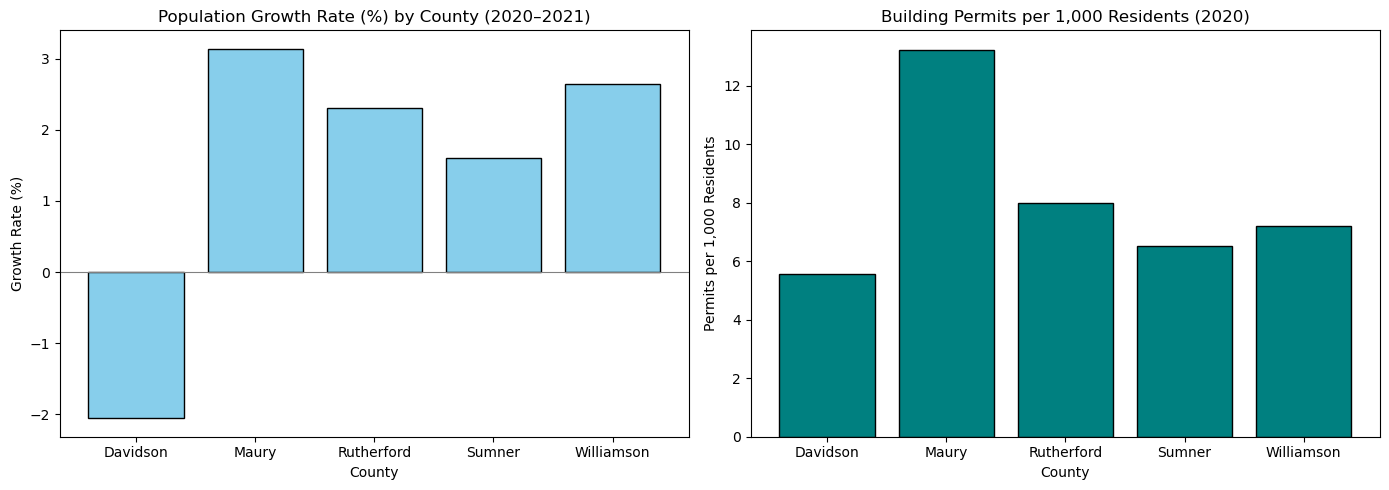

In [268]:
combined_df["Permits_Per_1000"] = (combined_df["building_permits"] / combined_df["population"]) * 1000

combined_df_pivot_pop = combined_df.pivot(
    index="clean_county", columns="year", values="population"
).reset_index()
combined_df_pivot_pop["Pop_Growth_pct"] = (
    (combined_df_pivot_pop[2021] - combined_df_pivot_pop[2020]) / combined_df_pivot_pop[2020]
) * 100

print("--- County Population Growth (2020-2021) ---")
print(combined_df_pivot_pop[["clean_county", "Pop_Growth_pct"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(
    combined_df_pivot_pop["clean_county"],
    combined_df_pivot_pop["Pop_Growth_pct"],
    color="skyblue",
    edgecolor="black",
)
axes[0].set_title("Population Growth Rate (%) by County (2020–2021)")
axes[0].set_ylabel("Growth Rate (%)")
axes[0].set_xlabel("County")
axes[0].axhline(0, color="gray", linewidth=0.8)


df_2020 = combined_df[combined_df["year"] == 2020].dropna(subset=["Permits_Per_1000"])
axes[1].bar(
    df_2020["clean_county"],
    df_2020["Permits_Per_1000"],
    color="teal",
    edgecolor="black",
)
axes[1].set_title("Building Permits per 1,000 Residents (2020)")
axes[1].set_ylabel("Permits per 1,000 Residents")
axes[1].set_xlabel("County")

plt.tight_layout()
plt.show()

Setting column to correct data type and sorting in order for proper aggregation

In [276]:
pricing['Date'] = pd.to_datetime(pricing['Date'])
pricing = pricing.sort_values('Date').reset_index(drop=True)

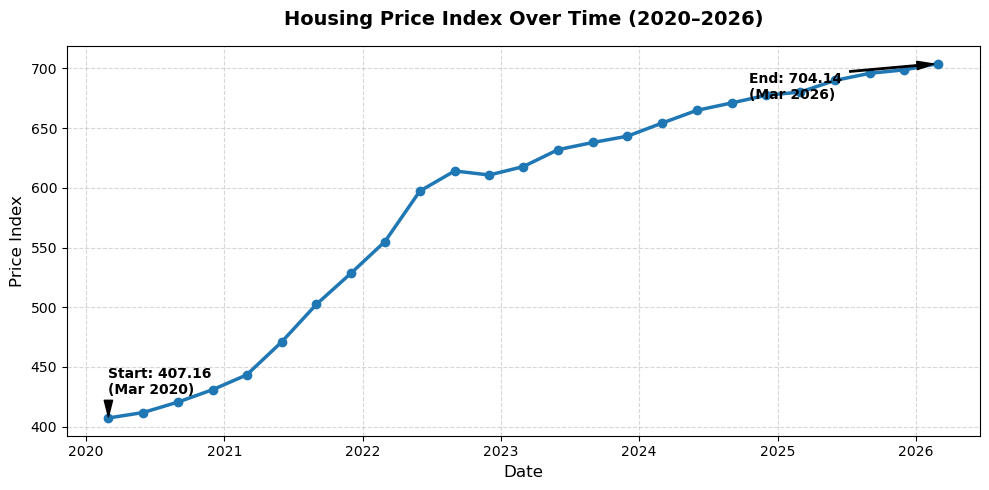

Start Value: 407.16
End Value: 704.14
Total Growth: 72.94%


In [278]:
plt.figure(figsize=(10, 5))
plt.plot(pricing['Date'], pricing['Price Index'], marker='o', color='#1f77b4', linewidth=2.5, label='Price Index')

plt.title('Housing Price Index Over Time (2020–2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Index', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

start_date, start_val = pricing.iloc[0]['Date'], pricing.iloc[0]['Price Index']
end_date, end_val = pricing.iloc[-1]['Date'], pricing.iloc[-1]['Price Index']

plt.annotate(f'Start: {start_val:.2f}\n({start_date.strftime("%b %Y")})',
             xy=(start_date, start_val), xytext=(start_date, start_val + 20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontweight='bold')

plt.annotate(f'End: {end_val:.2f}\n({end_date.strftime("%b %Y")})',
             xy=(end_date, end_val), xytext=(end_date - pd.Timedelta(days=500), end_val - 30),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontweight='bold')

plt.tight_layout()
plt.savefig('price_index_over_time.png', dpi=300)
plt.show()

total_growth_pct = ((end_val - start_val) / start_val) * 100
print(f"Start Value: {start_val}")
print(f"End Value: {end_val}")
print(f"Total Growth: {total_growth_pct:.2f}%")

Exporting datasets as csv to read into dashboards

In [279]:
combined_df.to_csv("capstone_summary.csv", index=False)

In [280]:
pricing.to_csv("capstone_pricing.csv", index=False)

In [283]:
df_pricing = pd.read_csv('../script/capstone_pricing.csv')
df_summary = pd.read_csv('../script/capstone_summary.csv')

df_pricing['Date'] = pd.to_datetime(df_pricing['Date'])
df_pricing['year'] = df_pricing['Date'].dt.year

pricing_annual = df_pricing.groupby('year')['Price Index'].mean().reset_index()
df_merged = pd.merge(df_summary, pricing_annual, on='year', how='left')

df_pricing['quarter'] = df_pricing['Date'].dt.to_period('Q').astype(str)

df_merged.to_csv('capstone_single_file.csv', index=False)